In [1]:
import warnings
import inspect
from copy import deepcopy
warnings.filterwarnings("ignore")
import logging
from statkit.decision import NetBenefitDisplay
import scipy
from sklearn.metrics import * 
import pandas as pd
import seaborn as sns
import numpy as np
import shap
import torch
import os
import inspect 
import torch.nn as nn
import matplotlib.pyplot as plt
import pickle
from numpy import sqrt
from numpy import argmax
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from matplotlib import pyplot
from torchinfo import summary as torchsummary
from torchvision import models, transforms
from model import init_model, init_transforms
from dataset import init_dataloader
from matplotlib import pyplot
from pathlib import Path
import inspect
sns.set(rc={'figure.figsize':(11.7,8.27)})
pd.options.display.max_rows = 999
pd.options.display.max_columns = 999




In [2]:
ROOT_DIR = Path(os.path.dirname(os.path.abspath('')))
TOTAL_TRAIN_SAMPLES = 50
TOTAL_TEST_SAMPLES = 10
CHANNELS = 3
DEVICE = "cuda:1"
OCT_PRESENCE = "Usando OCT"
DUAL_IMAGE = "Dual Image"
DATA_PATH = "../data.csv"
SUMMARY_PATH = "../model_summary.csv"
HISTORY_PATH = "../history.csv"
FT_SIZE = 24
ARQ1 = "SI"
ARQ2 = "SIT"
ARQ3 = "DI"
ARQ4 = "DIT"

In [3]:
def get_samples_from_loader(loader, size):
    """
    Return photos1, photos2, ft_numerical, labels
    """

    list_of_photos_1 = []
    list_of_photos_2 = []
    list_of_features = []
    list_of_labels = []

    for photos1, photos2, numericalft, labels in loader:
        for i in range(len(labels)):
            list_of_photos_1.append(photos1[i])
            list_of_photos_2.append(photos2[i])
            list_of_features.append(numericalft[i])
            list_of_labels.append(labels[i].numpy())

            if len(list_of_labels) >= size:
                break

        if len(list_of_labels) >= size:
            break

    photos1 = torch.stack(list_of_photos_1)
    photos2 = torch.stack(list_of_photos_2)
    ft_numerical = torch.stack(list_of_features)
    labels = np.array(list_of_labels)

    return (photos1, photos2, ft_numerical, labels)


In [4]:
def get_samples_from_loader_balanced(loader, size):
    """
    Return photos1, photos2, ft_numerical, labels
    """

    list_of_photos_1 = []
    list_of_photos_2 = []
    list_of_features = []
    list_of_labels = []

    positive_class = 0
    negative_class = 0

    for photos1, photos2, numericalft, labels in loader:
        for i in range(len(labels)):
            if int(labels[i].numpy()) == 0 and negative_class >= (size / 2):
                continue
            elif int(labels[i].numpy()) == 0 and negative_class < (size / 2):
                negative_class += 1

            if int(labels[i].numpy()) == 1 and positive_class >= (size / 2):
                continue
            elif int(labels[i].numpy()) == 1 and positive_class < (size / 2):
                positive_class += 1

            list_of_photos_1.append(photos1[i])
            list_of_photos_2.append(photos2[i])
            list_of_features.append(numericalft[i])
            list_of_labels.append(labels[i].numpy())

        if len(list_of_labels) >= size:
            break

    photos1 = torch.stack(list_of_photos_1)
    photos2 = torch.stack(list_of_photos_2)
    ft_numerical = torch.stack(list_of_features)
    labels = np.array(list_of_labels)

    return (photos1, photos2, ft_numerical, labels)


In [5]:
def load_model_and_loaders(model_row, model_id):
    """
        Return model, train_loader, val_loader
    """ 
    model_name = model_row["backbone"].values[0]
    pretrained = False
    feature_extract = False
    double_img_bool = False
    output_tab = 5 
    model, input_size = init_model(model_name,pretrained, double_img_bool, output_tab, FT_SIZE)
    model.load_state_dict(torch.load("../models/" + str(model_id) + "/" + "model"+ "_fold_1.pth"))
    train_loader = torch.load("../models/" + str(model_id) + "/train_dataloader" + "_fold_1.pth")
    val_loader = torch.load("../models/" + str(model_id) + "/val_dataloader" + "_fold_1.pth")
    
    val_loader.dataset.root_dir = ROOT_DIR
    train_loader.dataset.root_dir = ROOT_DIR
    
    return model, train_loader, val_loader, input_size

In [6]:
def create_explainers(model, device, photos1_train, photos2_train, ft_numerical_train, 
                                     photos1_val, photos2_val, ft_numerical_val, input_size):
    """
        Return shap_values_photo1, shap_values_photo2, shap_values_nuermical
    """ 
    
    model = model.to(device)
    explainer = shap.DeepExplainer(model, [photos1_train.to(device),photos2_train.to(device),ft_numerical_train.to(device)])
    shap_values_photo1, shap_values_photo2, shap_values_numerical = explainer.shap_values([photos1_val.to(device),photos2_val.to(device), ft_numerical_val.to(device)])
    
    photos1_list = []
    photos2_list = []
    for i in range(len(photos1_val)):
        photos1_list.append(imshow(photos1_val[i]))
        photos2_list.append(imshow(photos2_val[i]))
        
    
    photos1_numpy = np.asarray(photos1_list)
    photos2_numpy = np.asarray(photos2_list)
    
    return (shap_values_photo1.reshape(-1, input_size, input_size, CHANNELS), 
            shap_values_photo2.reshape(-1, input_size, input_size, CHANNELS), 
            shap_values_numerical,
            photos1_numpy, 
            photos2_numpy)

In [7]:
def plot_image(shap_values, photos, total):
    
    return shap.image_plot(shap_values[:total], photos[:total])

In [8]:
def imshow(image):
    npimg = image.numpy()
    npimg = np.transpose(npimg, (1,2,0))
    npimg = ((npimg * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406])
    return npimg

In [9]:
def shapley_feature_ranking(shap_values):
    feature_order = np.argsort(np.mean(np.abs(shap_values), axis=0))
    return pd.DataFrame(
        {
            "features": [numerical_columns[i] for i in feature_order][::-1],
            "importance": [
                np.mean(np.abs(shap_values), axis=0)[i] for i in feature_order
            ][::-1],
        }
    )

In [10]:
def get_rank_per_group(df_max,df_avg):
    dict_rows = {}
    dict_rows["Backbone"] = []
    dict_rows[OCT_PRESENCE] = []
    dict_rows[DUAL_IMAGE] = []
    dict_rows["Max Auc Rank"] = []
    dict_rows["Avg Auc Rank"] = []
 
 
    df_max = df_max.sort_values(by=["backbone",OCT_PRESENCE,DUAL_IMAGE])
    df_avg = df_avg.sort_values(by=["backbone",OCT_PRESENCE,DUAL_IMAGE])
    
    
    for index, row in df_max.iterrows():
        dict_rows["Backbone"].append(row["backbone"])
        dict_rows[OCT_PRESENCE].append(row[OCT_PRESENCE])
        dict_rows[DUAL_IMAGE].append(row[DUAL_IMAGE])
        dict_rows["Max Auc Rank"].append(row["rank_max_auc_oct_double"])
        
    for index, row in df_avg.iterrows():
        dict_rows["Avg Auc Rank"].append(row["rank_avg_auc_oct_double"])
        
    df_rank_per_group = pd.DataFrame.from_dict(dict_rows)
    return df_rank_per_group

In [80]:
def get_numpy(val_loader):
    photos1_val, photos2_val, ft_numerical_val, labels_val =  get_samples_from_loader(val_loader, len(val_loader.dataset))
    photos1_list = []
    photos2_list = []
    photos1_list_non_inv = []
    photos2_list_non_inv = []
    ft_numerical_list = []
    labels_list = []
    for i in range(len(photos1_val)):
        photos1_list.append(imshow(photos1_val[i]))
        photos2_list.append(imshow(photos2_val[i]))
        photos1_list_non_inv.append(deepcopy(photos1_val[i]))
        photos2_list_non_inv.append(deepcopy(photos2_val[i]))
        ft_numerical_list.append(ft_numerical_val[i].numpy())
        labels_list.append(labels_val[i])


    photos1_numpy = np.asarray(photos1_list)
    photos2_numpy = np.asarray(photos2_list)
    photos1_numpy_non_inv = np.asarray(photos1_list_non_inv)
    photos2_numpy_non_inv = np.asarray(photos2_list_non_inv)
    ft_numerical_numpy = np.asarray(ft_numerical_list)
    return photos1_numpy, photos2_numpy, photos1_numpy_non_inv, photos2_numpy_non_inv, ft_numerical_numpy, labels_list

In [81]:
data = pd.read_csv(DATA_PATH)
summary = pd.read_csv(SUMMARY_PATH)
filter_summary = pd.read_csv("../filter_top1.csv")
df_peak = pd.read_csv("../df_peak_mem_summary.csv")
history = pd.read_csv(HISTORY_PATH)
os.environ["NUM_WORKERS"] = "8"
device = "cuda"
important_columns = ['model_id', 'k_fold', 'frac_val', 'val_best_acc', 'val_best_auc','host_name', 'optim', 'lr', 'scheduler',
       'randaugop', 'epochs', 'double_img', 'output_tab', 'backbone',
       'early_start', 'patient_el','oos_best_auc',
       'avg_best_auc_oos','std_val_auc', 'std_oos_auc',
       'inference_time', 'avg_best_auc_val', 'max_sp_oos', 'max_sn_oos',
       'idx_max_sp_val', 'idx_max_sn_val', 'idx_avg_sp_val', 'idx_avg_sn_val',
       'avg_sp_oos', 'avg_sn_oos', 'std_sn_oos', 'std_sp_oos',
       'idx_std_sn_val', 'idx_std_sp_val']


In [82]:
model_id = "b674627d958947d79102841cdd7e2d90" 


In [83]:
row = summary[summary["model_id"] == model_id]
model, train_loader, val_loader, input_size =  load_model_and_loaders(row, model_id)
model = model.to(device)

In [84]:
row.squeeze()

model_id                   b674627d958947d79102841cdd7e2d90
k_fold                                                  5.0
frac_val                                                NaN
val_best_acc                                       0.986755
val_best_auc                                       0.990654
val_best_sp                                             1.0
val_best_sn                                             1.0
val_avg_acc                                          0.9134
val_avg_auc                                        0.873079
val_avg_sp                                          0.96875
val_avg_sn                                         0.777408
train_best_acc                                     0.963756
train_best_auc                                      0.94411
train_best_sp                                           1.0
train_best_sn                                      0.908537
train_avg_acc                                      0.926337
train_avg_auc                           

In [85]:
train = train_loader.dataset.glaucoma_data
val = val_loader.dataset.glaucoma_data
os.environ["NUM_WORKERS"] = "8"
numerical_columns = train.select_dtypes(include=np.number).columns.tolist()
numerical_columns.remove("label")
ft_size = len(numerical_columns)

In [86]:
transform_train ,transform_val,_ = init_transforms(224, 0)
train_loader = init_dataloader(train, transform_train, None, 16, numerical_columns, True, False)
val_loader = init_dataloader(val, transform_val, None, 16, numerical_columns, True, False)

In [87]:
(
photos1_train,
photos2_train,
ft_numerical_train,
_,
) = get_samples_from_loader_balanced(train_loader, 50)

In [88]:
(
    photos1_val,
    photos2_val,
    ft_numerical_val,
    _,
) = get_samples_from_loader(val_loader, len(val_loader.dataset))


In [89]:
val_loader.dataset.double_img

True

In [96]:
explainer = shap.DeepExplainer(
    model,
    [
        photos1_train.to(device),
        photos2_train.to(device),
        ft_numerical_train.to(device),
    ],
)


In [97]:
(
    shap_values_photo1,
    shap_values_photo2,
    shap_values_numerical,
) = explainer.shap_values([photos1_val, photos2_val, ft_numerical_val])


In [98]:
df = val_loader.dataset.glaucoma_data

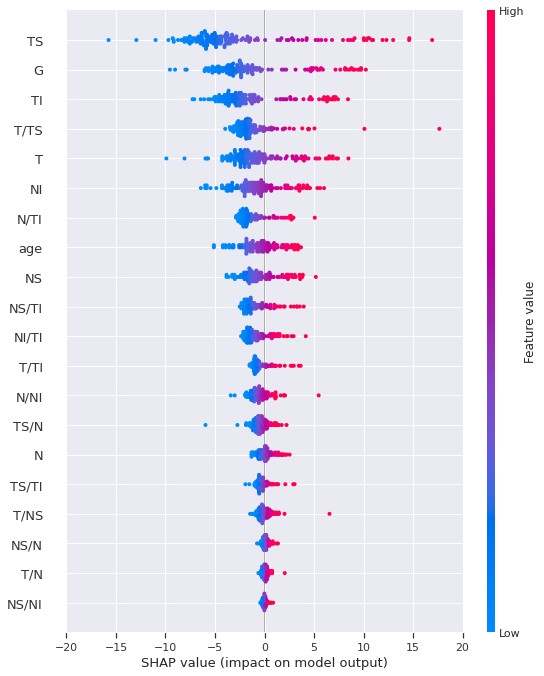

In [117]:
plt.xlim(xmin=-20,xmax=20) 
shap.summary_plot(shap_values_numerical, shap_values_numerical, feature_names=df.iloc[:,5:].columns.values,  layered_violin_max_num_bins=40, show=False)

In [118]:
(
    shap_values_photo1,
    shap_values_photo2,
    shap_values_numerical,
) = explainer.shap_values([photos1_train, photos2_train, ft_numerical_train])


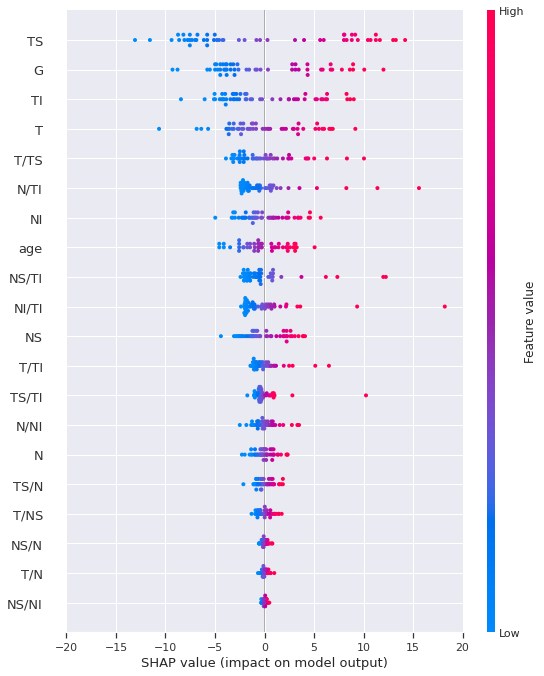

In [119]:
plt.xlim(xmin=-20,xmax=20) 
shap.summary_plot(shap_values_numerical, shap_values_numerical, feature_names=df.iloc[:,5:].columns.values)

## Average Importance

In [26]:
cross_tab = summary[(summary["k_fold"] == 5) & (summary["output_tab"] == 5)]

In [27]:
cross_tab

,model_id,k_fold,frac_val,val_best_acc,val_best_auc,val_best_sp,val_best_sn,val_avg_acc,val_avg_auc,val_avg_sp,val_avg_sn,train_best_acc,train_best_auc,train_best_sp,train_best_sn,train_avg_acc,train_avg_auc,train_avg_sp,train_avg_sn,host_name,optim,lr,scheduler,randaugop,epochs,double_img,output_tab,backbone,early_start,patient_el,timestamp,total_hours,average_cross_hours,torchvision_version,torch_version,history_added,shap_val,shap_oos,pred_val,pred_oos,batch_size,Usando OCT,Dual Image,group_backbone,regnet_vs_other,rank_max_auc,rank_avg_auc,oos_best_auc,avg_best_auc_oos,rank_max_auc_oct_double,rank_avg_auc_oct_double,rank_avg,std_val_auc,std_oos_auc,inference_time,avg_best_auc_val,max_sp_oos,max_sn_oos,idx_max_sp_val,idx_max_sn_val,idx_avg_sp_val,idx_avg_sn_val,avg_sp_oos,avg_sn_oos,std_sn_oos,std_sp_oos,idx_std_sn_val,idx_std_sp_val
864,86d27a1507a8431aada713f3f2b49a86,5.0,NaN,0.960526,0.943170,1.0,0.941176,0.791080,0.656461,0.978400,0.334521,0.963696,0.951526,1.0,0.921788,0.808277,0.663284,0.991119,0.335449,magneto,adam,0.0100,plateau,0,100.0,0.0,5.0,resnet,30.0,10.0,2022-12-20 16:50:38.557859,40:37:53.55,08:07:34.69,0.13.0+cu113,1.12.0+cu113,1.0,0,0,1,1,16,NaN,NaN,NaN,NaN,NaN,NaN,0.848485,0.633333,NaN,NaN,NaN,0.211740,0.163580,0.043,0.672788,1.000000,0.696970,1.000000,0.911765,0.993010,0.352566,1.000000,0.266667,0.327160,0.000000,0.432229,0.009928
865,1c6f3dc7ee844662b288be93b1c91235,5.0,NaN,0.947368,0.944562,1.0,0.954545,0.871546,0.817530,0.937668,0.697391,0.978583,0.972441,1.0,0.958580,0.916915,0.877610,0.967800,0.787419,magneto,adam,0.0005,plateau,0,100.0,0.0,5.0,regnet32y,30.0,10.0,2022-12-20 17:05:17.191984,40:54:24.74,08:10:52.93,0.13.0+cu113,1.12.0+cu113,1.0,1,1,1,1,16,NaN,NaN,NaN,NaN,NaN,NaN,0.810945,0.750249,NaN,NaN,NaN,0.034091,0.040288,0.043,0.896606,1.000000,0.666667,0.982301,0.954545,0.950853,0.842359,0.967164,0.533333,0.073231,0.025679,0.063598,0.026536
866,f13247f5d3414429857dbe30480d27b8,5.0,NaN,0.947368,0.928215,1.0,1.000000,0.871232,0.816939,0.943499,0.690378,0.980231,0.965335,1.0,0.932927,0.906883,0.858828,0.968249,0.749407,magneto,radam,0.0100,plateau,0,100.0,0.0,5.0,mobile,30.0,10.0,2022-12-20 18:25:09.029183,42:10:16.87,08:26:03.35,0.13.0+cu113,1.12.0+cu113,1.0,1,1,1,1,16,NaN,NaN,NaN,NaN,NaN,NaN,0.871325,0.775848,NaN,NaN,NaN,0.036641,0.068165,0.036,0.892337,1.000000,0.757576,1.000000,0.941176,0.945996,0.838677,0.988060,0.563636,0.132227,0.011169,0.066150,0.031780
867,ee824607e9f04221880088fcb2543986,5.0,NaN,0.973510,0.981308,1.0,1.000000,0.903793,0.863677,0.956564,0.770790,0.981848,0.972970,1.0,0.966480,0.937128,0.903996,0.979303,0.828688,magneto,ranger,0.0100,plateau,0,100.0,0.0,5.0,shuffle,30.0,10.0,2022-12-20 18:28:14.919040,42:12:45.79,08:26:33.13,0.13.0+cu113,1.12.0+cu113,1.0,1,1,1,1,16,NaN,NaN,NaN,NaN,NaN,NaN,0.863636,0.827318,NaN,NaN,NaN,0.029736,0.035347,0.046,0.935054,1.000000,0.727273,0.974576,1.000000,0.963071,0.907038,0.994030,0.660606,0.072727,0.011940,0.054609,0.008969
868,371f2592f8994c818e30a732c23aeaf6,5.0,NaN,0.921053,0.925972,1.0,0.970588,0.822139,0.756661,0.911556,0.601765,0.966997,0.955490,1.0,0.927374,0.886432,0.830614,0.957571,0.703657,magneto,radam,0.0010,plateau,0,100.0,0.0,5.0,shuffle,30.0,10.0,2022-12-20 18:35:37.071506,42:23:48.03,08:28:45.59,0.13.0+cu113,1.12.0+cu113,1.0,1,1,1,1,16,NaN,NaN,NaN,NaN,NaN,NaN,0.750565,0.687246,NaN,NaN,NaN,0.078605,0.043177,0.041,0.825964,0.925373,0.575758,0.953271,0.970588,0.923825,0.728102,0.883582,0.490909,0.075210,0.023881,0.164027,0.026995
869,564ce1d63d4643a5a14005274a6715a2,5.0,NaN,0.914474,0.903041,1.0,0.911765,0.800148,0.722816,0.905366,0.540266,0.935644,0.917470,1.0,0.877095,0.858810,0.789403,0.947451,0.631355,magneto,ranger,0.0010,plateau,0,100.0,0.0,5.0,shuffle,30.0,10.0,2022-12-20 18:38:01.790833,42:26:53.13,08:29:22.60,0.13.0+cu113,1.12.0+cu113,1.0,1,1,1,1,16,NaN,NaN,NaN,NaN,NaN,NaN,0.712800,0.688874,NaN,NaN,NaN,0.070036,0.033600,0.041,0.795280,0.910448,0.606061,0.971429,0.882353,0.927145,0.663414,0.868657,0.509091,0.067488,0.03

In [28]:
summary[summary["model_id"] == "86d27a1507a8431aada713f3f2b49a86"]

,model_id,k_fold,frac_val,val_best_acc,val_best_auc,val_best_sp,val_best_sn,val_avg_acc,val_avg_auc,val_avg_sp,val_avg_sn,train_best_acc,train_best_auc,train_best_sp,train_best_sn,train_avg_acc,train_avg_auc,train_avg_sp,train_avg_sn,host_name,optim,lr,scheduler,randaugop,epochs,double_img,output_tab,backbone,early_start,patient_el,timestamp,total_hours,average_cross_hours,torchvision_version,torch_version,history_added,shap_val,shap_oos,pred_val,pred_oos,batch_size,Usando OCT,Dual Image,group_backbone,regnet_vs_other,rank_max_auc,rank_avg_auc,oos_best_auc,avg_best_auc_oos,rank_max_auc_oct_double,rank_avg_auc_oct_double,rank_avg,std_val_auc,std_oos_auc,inference_time,avg_best_auc_val,max_sp_oos,max_sn_oos,idx_max_sp_val,idx_max_sn_val,idx_avg_sp_val,idx_avg_sn_val,avg_sp_oos,avg_sn_oos,std_sn_oos,std_sp_oos,idx_std_sn_val,idx_std_sp_val
864,86d27a1507a8431aada713f3f2b49a86,5.0,NaN,0.960526,0.94317,1.0,0.941176,0.79108,0.656461,0.9784,0.334521,0.963696,0.951526,1.0,0.921788,0.808277,0.663284,0.991119,0.335449,magneto,adam,0.01,plateau,0,100.0,0.0,5.0,resnet,30.0,10.0,2022-12-20 16:50:38.557859,40:37:53.55,08:07:34.69,0.13.0+cu113,1.12.0+cu113,1.0,0,0,1,1,16,NaN,NaN,NaN,NaN,NaN,NaN,0.848485,0.633333,NaN,NaN,NaN,0.21174,0.16358,0.043,0.672788,1.0,0.69697,1.0,0.911765,0.99301,0.352566,1.0,0.266667,0.32716,0.0,0.432229,0.009928


In [37]:
def ranking_importance(model_id):
    print(model_id)
    row = summary[summary["model_id"] == model_id]
    model, train_loader, val_loader, input_size =  load_model_and_loaders(row, model_id)
    model = model.to(device)
    train = train_loader.dataset.glaucoma_data
    val = val_loader.dataset.glaucoma_data
    numerical_columns = train.select_dtypes(include=np.number).columns.tolist()
    numerical_columns.remove("label")
    ft_size = len(numerical_columns)
    transform_train ,transform_val,_ = init_transforms(input_size, 0)
    train_loader = init_dataloader(train, transform_train, None, 16, numerical_columns, False, False)
    val_loader = init_dataloader(val, transform_val, None, 16, numerical_columns, False, False)
    (
    photos1_train,
    photos2_train,
    ft_numerical_train,
    _,
    ) = get_samples_from_loader_balanced(train_loader, 50)
    (
    photos1_val,
    photos2_val,
    ft_numerical_val,
    _,
    ) = get_samples_from_loader(val_loader, len(val_loader.dataset))
    explainer = shap.DeepExplainer(
    model,
    [
        photos1_train.to(device),
        photos2_train.to(device),
        ft_numerical_train.to(device),
    ],
    )
    (
    shap_values_photo1,
    shap_values_photo2,
    shap_values_numerical,
    ) = explainer.shap_values([photos1_val, photos2_val, ft_numerical_val])
    df_importance = shapley_feature_ranking(shap_values_numerical)
    df_importance["rank"] = df_importance["importance"].rank(ascending=False,method="first").astype(int)
    df_importance.set_index("features",inplace=True)
    df_importance = df_importance.transpose()
    df_importance["model_id"] = model_id
    df_importance["dataset"] = "test"
    df_importance["metric"] = df_importance.index.values
    df_importance.reset_index(drop=True, inplace=True)
    df_importance["backbone"] = summary[summary["model_id"] == model_id]["backbone"].values[0]
    df_importance["model_id"] = model_id
    return df_importance

In [38]:
model_ids = cross_tab["model_id"].values.tolist()

In [46]:
all_imp = []
for idx in model_ids[20:22]:
    df_importance = ranking_importance(idx)
    all_imp.append(df_importance)
    torch.cuda.empty_cache() 

b674627d958947d79102841cdd7e2d90
86200d909a164bb58e2cfb12bf8cbb60


In [47]:
importance_df = pd.concat(all_imp)

In [48]:
importance_df

features,TS,G,TI,T/TS,T,NI,N/TI,age,NS,NS/TI,NI/TI,T/TI,N/NI,TS/N,N,TS/TI,T/NS,NS/N,T/N,NS/NI,gender,TS/NI,T/NI,TS/NS,model_id,dataset,metric,backbone
0,5.806873,3.896481,3.460860,2.565501,2.547038,2.045982,1.822739,1.525161,1.522082,1.463885,1.330644,0.909405,0.875792,0.660167,0.592932,0.522374,0.493756,0.236875,0.212080,0.151571,0.090246,0.085252,0.082803,0.008255,b674627d958947d79102841cdd7e2d90,test,importance,regnet16x
1,1.000000,2.000000,3.000000,4.000000,5.000000,6.000000,7.000000,8.000000,9.000000,10.000000,11.000000,12.000000,13.000000,14.000000,15.000000,16.000000,17.000000,18.000000,19.000000,20.000000,21.000000,22.000000,23.000000,24.000000,b674627d958947d79102841cdd7e2d90,test,rank,regnet16x
0,2.160094,0.777931,0.974685,0.767162,0.894930,0.250933,0.461788,0.599872,0.771461,0.593803,0.367913,0.213986,0.380562,0.092536,0.421970,0.091063,0.177295,0.028549,0.081583,0.075242,0.126532,0.111141,0.080082,0.030254,86200d909a164bb58e2cfb12bf8cbb60,test,importance,inception
1,1.000000,4.000000,2.000000,6.000000,3.000000,13.000000,9.000000,7.000000,5.000000,8.000000,12.000000,14.000000,11.000000,18.000000,10.000000,19.000000,15.000000,24.000000,20.000000,22.000000,16.000000,17.000000,21.000000,23.000000,86200d909a164bb58e2cfb12bf8cbb60,test,rank,inception


In [56]:
imp_df = importance_df[importance_df["metric"] == "importance"]
imp_df = imp_df.groupby("backbone").mean()
imp_df

features,TS,G,TI,T/TS,T,NI,N/TI,age,NS,NS/TI,NI/TI,T/TI,N/NI,TS/N,N,TS/TI,T/NS,NS/N,T/N,NS/NI,gender,TS/NI,T/NI,TS/NS
backbone,,,,,,,,,,,,,,,,,,,,,,,,
inception,2.160094,0.777931,0.974685,0.767162,0.894930,0.250933,0.461788,0.599872,0.771461,0.593803,0.367913,0.213986,0.380562,0.092536,0.421970,0.091063,0.177295,0.028549,0.081583,0.075242,0.126532,0.111141,0.080082,0.030254
regnet16x,5.806873,3.896481,3.460860,2.565501,2.547038,2.045982,1.822739,1.525161,1.522082,1.463885,1.330644,0.909405,0.875792,0.660167,0.592932,0.522374,0.493756,0.236875,0.212080,0.151571,0.090246,0.085252,0.082803,0.008255


<AxesSubplot:xlabel='features', ylabel='backbone'>

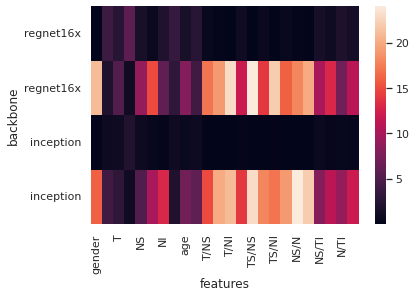

In [51]:
sns.heatmap(importance_df.set_index("backbone")[numerical_columns])